# [7.4] Mini Natural Language Autoencoders - Solutions

**By the end of this notebook, you will have shown that a four-phrase natural-language bottleneck recovers two planted semantic variables from held-out activations and preserves their downstream behavior, while prompt-only and wrong-phrase controls fail.**

```python
GT_TIER = "GT-3"
EXERCISE_ID = "7_4_mini_natural_language_autoencoders"
EXPECTED_RUNTIME = "seconds on the exact CPU contract; minutes on the live parent CUDA preflight"
REQUIRES_GPU = True
```

## Core Question

Can a short, readable phrase carry the behaviorally relevant information in an activation without secretly copying its numerical coordinates?

## Learning Objectives

- construct a model organism with exact semantic and nuisance directions;
- encode activations into compositional natural-language phrases;
- reconstruct activations from words rather than phrase IDs;
- test activation MSE, latent recovery, and downstream behavior separately;
- falsify shortcut explanations with paired prompts and opposite-phrase controls;
- intervene on one known activation direction and predict the textual and behavioral result.

## Cold Open

The visible prompt is identical in every row below:

> `The courier reads sealed card 06 before choosing the next move.`

Yet the model organism can internally plan any of four states:

| hidden route | hidden cargo | desired explanation |
|---|---|---|
| north | fragile | `route north; cargo fragile` |
| north | standard | `route north; cargo standard` |
| south | fragile | `route south; cargo fragile` |
| south | standard | `route south; cargo standard` |

A text-only system sees the same sentence four times, so it cannot know which state is active. The activation can. This paired construction is the ground truth against which every later result is judged.

The miniature NLA has two learned maps:

```text
activation --linear encoder--> semantic bits --words--> short phrase
short phrase --bag of semantic words + ridge decoder--> reconstructed activation
```

The route and cargo axes are exact. Prompt-specific variation lives in orthogonal nuisance directions. The decoder is allowed to discard that nuisance if it preserves the computation we care about.

In [1]:
import re
import json
import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import torch as t
import torch.nn.functional as F
from IPython.display import Markdown, display

chapter = "chapter7_activation_to_language"
root_dir = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / chapter).exists())
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))
section_dir = root_dir / chapter / "exercises" / "part4_mini_natural_language_autoencoders"
from chapter7_activation_to_language.exercises.part4_mini_natural_language_autoencoders import tests

SEMANTIC_VOCABULARY = ("north", "south", "fragile", "standard")
ANTIPODAL_PHRASE = {
    "route north; cargo fragile": "route south; cargo standard",
    "route north; cargo standard": "route south; cargo fragile",
    "route south; cargo fragile": "route north; cargo standard",
    "route south; cargo standard": "route north; cargo fragile",
}

@dataclass(frozen=True)
class PlantedNLADataset:
    activations: t.Tensor
    latent_bits: t.Tensor
    prompts: tuple[str, ...]
    phrases: tuple[str, ...]
    split_ids: t.Tensor
    semantic_directions: t.Tensor
    nuisance_directions: t.Tensor
    behavior_direction: t.Tensor

@dataclass(frozen=True)
class ReconstructionComparison:
    nla_mse: float
    prompt_only_mse: float
    shuffled_phrase_mse: float
    mean_cosine: float
    nla_beats_prompt_only: bool
    shuffled_control_fails: bool

@dataclass(frozen=True)
class BehaviorPreservation:
    nla_mae: float
    prompt_only_mae: float
    shuffled_phrase_mae: float
    route_accuracy: float
    cargo_accuracy: float
    behavior_sign_accuracy: float
    nla_beats_controls: bool

t.manual_seed(0)
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})

### Exercise - build the exact activation model organism

> ```yaml
> Difficulty: easy
> Importance: high
> You should spend up to 10-15 minutes on this exercise.
> ```

Implement `latent_phrase` and `make_planted_nla_dataset`. Every prompt must occur with all four hidden states, and semantic coordinates must be exactly known before any learned claim is made.

<details>
<summary>Expected output</summary>

`40 x 8` activations; orthonormal semantic axes; exact coordinates `(+/-2.5, +/-2.0)`; all tests pass.

</details>

<details>
<summary>Help - keep semantics separate from nuisance</summary>

Use QR decomposition to obtain orthonormal directions. Add route, cargo, and an orthogonal prompt-nuisance vector. Repeat every prompt over all four sign pairs.

Common bug: pairing each prompt with only one hidden state. That leaks the answer through prompt identity and invalidates the prompt-only control.

</details>

<details>
<summary>Interpretation</summary>

The paired prompts prove that visible text alone contains zero information about the hidden route or cargo. This is an exact control, not an empirical hunch.

</details>

<details>
<summary>Solution</summary>

```python
def latent_phrase(latent_bits: t.Tensor) -> str:
    """Turn the two planted semantic bits into a short compositional phrase."""

    if latent_bits.shape != (2,):
        raise ValueError("latent_bits must have shape (2,).")
    route = "north" if float(latent_bits[0]) > 0 else "south"
    cargo = "fragile" if float(latent_bits[1]) > 0 else "standard"
    return f"route {route}; cargo {cargo}"

def make_planted_nla_dataset(
    *,
    seed: int = 0,
    d_model: int = 8,
    train_prompt_count: int = 6,
    eval_prompt_count: int = 4,
    nuisance_scale: float = 0.35,
) -> PlantedNLADataset:
    """Build paired prompts whose hidden activation contains two known semantic bits."""

    if d_model < 4:
        raise ValueError("d_model must be at least 4.")
    if train_prompt_count < 2 or eval_prompt_count < 2:
        raise ValueError("each split needs at least two prompt groups.")
    if nuisance_scale < 0:
        raise ValueError("nuisance_scale must be non-negative.")

    generator = t.Generator().manual_seed(seed)
    basis, _ = t.linalg.qr(t.randn(d_model, d_model, generator=generator))
    semantic_directions = basis[:, :2].T.contiguous()
    nuisance_directions = basis[:, 2:4].T.contiguous()
    behavior_direction = 1.4 * semantic_directions[0] + 0.8 * semantic_directions[1]

    activations: list[t.Tensor] = []
    latent_rows: list[tuple[float, float]] = []
    prompts: list[str] = []
    phrases: list[str] = []
    split_ids: list[int] = []
    latent_states = ((1.0, 1.0), (1.0, -1.0), (-1.0, 1.0), (-1.0, -1.0))

    for split_id, prompt_count, offset in (
        (0, train_prompt_count, 0),
        (1, eval_prompt_count, train_prompt_count),
    ):
        for prompt_index in range(prompt_count):
            angle = 2 * t.pi * prompt_index / prompt_count
            nuisance = nuisance_scale * (
                t.cos(t.tensor(angle)) * nuisance_directions[0]
                + t.sin(t.tensor(angle)) * nuisance_directions[1]
            )
            prompt = (
                f"The courier reads sealed card {offset + prompt_index:02d} "
                "before choosing the next move."
            )
            for route_bit, cargo_bit in latent_states:
                bits = t.tensor([route_bit, cargo_bit])
                activation = (
                    2.5 * route_bit * semantic_directions[0]
                    + 2.0 * cargo_bit * semantic_directions[1]
                    + nuisance
                )
                activations.append(activation)
                latent_rows.append((route_bit, cargo_bit))
                prompts.append(prompt)
                phrases.append(latent_phrase(bits))
                split_ids.append(split_id)

    return PlantedNLADataset(
        activations=t.stack(activations),
        latent_bits=t.tensor(latent_rows),
        prompts=tuple(prompts),
        phrases=tuple(phrases),
        split_ids=t.tensor(split_ids, dtype=t.long),
        semantic_directions=semantic_directions,
        nuisance_directions=nuisance_directions,
        behavior_direction=behavior_direction,
    )
```

</details>

In [2]:
def latent_phrase(latent_bits: t.Tensor) -> str:
    """Turn the two planted semantic bits into a short compositional phrase."""

    if latent_bits.shape != (2,):
        raise ValueError("latent_bits must have shape (2,).")
    route = "north" if float(latent_bits[0]) > 0 else "south"
    cargo = "fragile" if float(latent_bits[1]) > 0 else "standard"
    return f"route {route}; cargo {cargo}"

def make_planted_nla_dataset(
    *,
    seed: int = 0,
    d_model: int = 8,
    train_prompt_count: int = 6,
    eval_prompt_count: int = 4,
    nuisance_scale: float = 0.35,
) -> PlantedNLADataset:
    """Build paired prompts whose hidden activation contains two known semantic bits."""

    if d_model < 4:
        raise ValueError("d_model must be at least 4.")
    if train_prompt_count < 2 or eval_prompt_count < 2:
        raise ValueError("each split needs at least two prompt groups.")
    if nuisance_scale < 0:
        raise ValueError("nuisance_scale must be non-negative.")

    generator = t.Generator().manual_seed(seed)
    basis, _ = t.linalg.qr(t.randn(d_model, d_model, generator=generator))
    semantic_directions = basis[:, :2].T.contiguous()
    nuisance_directions = basis[:, 2:4].T.contiguous()
    behavior_direction = 1.4 * semantic_directions[0] + 0.8 * semantic_directions[1]

    activations: list[t.Tensor] = []
    latent_rows: list[tuple[float, float]] = []
    prompts: list[str] = []
    phrases: list[str] = []
    split_ids: list[int] = []
    latent_states = ((1.0, 1.0), (1.0, -1.0), (-1.0, 1.0), (-1.0, -1.0))

    for split_id, prompt_count, offset in (
        (0, train_prompt_count, 0),
        (1, eval_prompt_count, train_prompt_count),
    ):
        for prompt_index in range(prompt_count):
            angle = 2 * t.pi * prompt_index / prompt_count
            nuisance = nuisance_scale * (
                t.cos(t.tensor(angle)) * nuisance_directions[0]
                + t.sin(t.tensor(angle)) * nuisance_directions[1]
            )
            prompt = (
                f"The courier reads sealed card {offset + prompt_index:02d} "
                "before choosing the next move."
            )
            for route_bit, cargo_bit in latent_states:
                bits = t.tensor([route_bit, cargo_bit])
                activation = (
                    2.5 * route_bit * semantic_directions[0]
                    + 2.0 * cargo_bit * semantic_directions[1]
                    + nuisance
                )
                activations.append(activation)
                latent_rows.append((route_bit, cargo_bit))
                prompts.append(prompt)
                phrases.append(latent_phrase(bits))
                split_ids.append(split_id)

    return PlantedNLADataset(
        activations=t.stack(activations),
        latent_bits=t.tensor(latent_rows),
        prompts=tuple(prompts),
        phrases=tuple(phrases),
        split_ids=t.tensor(split_ids, dtype=t.long),
        semantic_directions=semantic_directions,
        nuisance_directions=nuisance_directions,
        behavior_direction=behavior_direction,
    )

tests.test_planted_dataset_has_exact_semantic_ground_truth(make_planted_nla_dataset, latent_phrase)

All tests in `test_planted_dataset_has_exact_semantic_ground_truth` passed!


### Exercise - turn phrases into compositional text features

> ```yaml
> Difficulty: easy
> Importance: high
> You should spend up to 5-10 minutes on this exercise.
> ```

Implement `phrase_feature_matrix`. The same words in a different order must produce the same vector; a four-way phrase-ID lookup is not allowed.

<details>
<summary>Expected output</summary>

`route north; cargo fragile` maps to `[1, 0, 1, 0]`; reordering its words leaves the vector unchanged.

</details>

<details>
<summary>Help - compose words rather than phrase IDs</summary>

Lowercase the phrase, extract alphabetic words, then mark the presence of `north`, `south`, `fragile`, and `standard`.

</details>

<details>
<summary>Interpretation</summary>

This is still a tiny vocabulary, but it forces the decoder to consume word meanings compositionally rather than an opaque class ID.

</details>

<details>
<summary>Solution</summary>

```python
def phrase_feature_matrix(
    phrases: list[str] | tuple[str, ...],
    vocabulary: tuple[str, ...] = SEMANTIC_VOCABULARY,
) -> t.Tensor:
    """Represent phrases by semantic word presence, never by phrase identity."""

    if not phrases:
        raise ValueError("phrases must be nonempty.")
    if len(set(vocabulary)) != len(vocabulary) or not vocabulary:
        raise ValueError("vocabulary must contain unique tokens.")
    rows = []
    for phrase in phrases:
        words = set(re.findall(r"[a-z]+", phrase.lower()))
        row = [float(token in words) for token in vocabulary]
        if sum(row) != 2:
            raise ValueError("each phrase must contain one route word and one cargo word.")
        rows.append(row)
    return t.tensor(rows, dtype=t.float32)
```

</details>

In [3]:
def phrase_feature_matrix(
    phrases: list[str] | tuple[str, ...],
    vocabulary: tuple[str, ...] = SEMANTIC_VOCABULARY,
) -> t.Tensor:
    """Represent phrases by semantic word presence, never by phrase identity."""

    if not phrases:
        raise ValueError("phrases must be nonempty.")
    if len(set(vocabulary)) != len(vocabulary) or not vocabulary:
        raise ValueError("vocabulary must contain unique tokens.")
    rows = []
    for phrase in phrases:
        words = set(re.findall(r"[a-z]+", phrase.lower()))
        row = [float(token in words) for token in vocabulary]
        if sum(row) != 2:
            raise ValueError("each phrase must contain one route word and one cargo word.")
        rows.append(row)
    return t.tensor(rows, dtype=t.float32)

tests.test_phrase_features_are_compositional(phrase_feature_matrix)

All tests in `test_phrase_features_are_compositional` passed!


### Exercise - learn activation to phrase encoding

> ```yaml
> Difficulty: medium
> Importance: high
> You should spend up to 15-20 minutes on this exercise.
> ```

Implement a ridge encoder from activations to the two semantic bits, then render the predicted signs as phrases. Train only on cards 00-05 and evaluate on unseen cards 06-09.

<details>
<summary>Expected output</summary>

Held-out phrase accuracy is `1.0` across all 16 unseen-card activations.

</details>

<details>
<summary>Help - fit on train rows and decode held-out rows</summary>

Center the training activations, solve the ridge normal equations for two outputs, and classify each output by its sign.

</details>

<details>
<summary>Interpretation</summary>

Generalization works because nuisance is orthogonal to the planted semantic subspace. Later you will deliberately increase nuisance to find the boundary.

</details>

<details>
<summary>Solution</summary>

```python
def fit_activation_encoder(
    train_activations: t.Tensor,
    train_latent_bits: t.Tensor,
    *,
    ridge: float = 1e-5,
) -> tuple[t.Tensor, t.Tensor]:
    """Fit a linear activation-to-two-bit encoder by ridge regression."""

    if train_activations.ndim != 2 or train_latent_bits.shape != (len(train_activations), 2):
        raise ValueError("expected activations [batch, d_model] and latent bits [batch, 2].")
    if ridge <= 0:
        raise ValueError("ridge must be positive.")
    mean = train_activations.mean(dim=0)
    centered = train_activations - mean
    eye = t.eye(centered.shape[1], device=centered.device, dtype=centered.dtype)
    weight = t.linalg.solve(centered.T @ centered + ridge * eye, centered.T @ train_latent_bits)
    bias = -mean @ weight
    return weight, bias

def encode_activations_to_phrases(
    activations: t.Tensor,
    encoder_weight: t.Tensor,
    encoder_bias: t.Tensor,
) -> tuple[tuple[str, ...], t.Tensor]:
    """Encode residuals into two semantic bits and render them as phrases."""

    if activations.ndim != 2:
        raise ValueError("activations must have shape [batch, d_model].")
    scores = activations @ encoder_weight + encoder_bias
    if scores.shape != (len(activations), 2):
        raise ValueError("encoder must produce exactly two semantic scores.")
    predicted_bits = t.where(scores >= 0, t.ones_like(scores), -t.ones_like(scores))
    phrases = tuple(latent_phrase(bits) for bits in predicted_bits)
    return phrases, predicted_bits
```

</details>

In [4]:
def fit_activation_encoder(
    train_activations: t.Tensor,
    train_latent_bits: t.Tensor,
    *,
    ridge: float = 1e-5,
) -> tuple[t.Tensor, t.Tensor]:
    """Fit a linear activation-to-two-bit encoder by ridge regression."""

    if train_activations.ndim != 2 or train_latent_bits.shape != (len(train_activations), 2):
        raise ValueError("expected activations [batch, d_model] and latent bits [batch, 2].")
    if ridge <= 0:
        raise ValueError("ridge must be positive.")
    mean = train_activations.mean(dim=0)
    centered = train_activations - mean
    eye = t.eye(centered.shape[1], device=centered.device, dtype=centered.dtype)
    weight = t.linalg.solve(centered.T @ centered + ridge * eye, centered.T @ train_latent_bits)
    bias = -mean @ weight
    return weight, bias

def encode_activations_to_phrases(
    activations: t.Tensor,
    encoder_weight: t.Tensor,
    encoder_bias: t.Tensor,
) -> tuple[tuple[str, ...], t.Tensor]:
    """Encode residuals into two semantic bits and render them as phrases."""

    if activations.ndim != 2:
        raise ValueError("activations must have shape [batch, d_model].")
    scores = activations @ encoder_weight + encoder_bias
    if scores.shape != (len(activations), 2):
        raise ValueError("encoder must produce exactly two semantic scores.")
    predicted_bits = t.where(scores >= 0, t.ones_like(scores), -t.ones_like(scores))
    phrases = tuple(latent_phrase(bits) for bits in predicted_bits)
    return phrases, predicted_bits

tests.test_activation_encoder_recovers_held_out_phrases(make_planted_nla_dataset, fit_activation_encoder, encode_activations_to_phrases)

All tests in `test_activation_encoder_recovers_held_out_phrases` passed!


### Exercise - learn phrase to activation reconstruction

> ```yaml
> Difficulty: medium
> Importance: high
> You should spend up to 15-20 minutes on this exercise.
> ```

Implement the phrase decoder with a bias term. It must reconstruct semantic coordinates from word features and cannot receive the prompt or activation.

<details>
<summary>Expected output</summary>

The four decoded phrases recover semantic coordinates `(+/-2.5, +/-2.0)` and contain no nuisance component.

</details>

<details>
<summary>Help - reconstruct from word features</summary>

Append a column of ones to the phrase features, solve ridge regression to activation space, and leave the bias unregularized.

</details>

<details>
<summary>Interpretation</summary>

The reconstruction is intentionally lossy: it keeps the two causal semantic directions and removes prompt-specific nuisance.

</details>

<details>
<summary>Solution</summary>

```python
def fit_phrase_decoder(
    train_phrases: list[str] | tuple[str, ...],
    train_activations: t.Tensor,
    *,
    ridge: float = 1e-5,
) -> tuple[t.Tensor, t.Tensor]:
    """Fit a compositional semantic-word-to-activation ridge decoder."""

    features = phrase_feature_matrix(train_phrases).to(train_activations)
    if train_activations.ndim != 2 or len(features) != len(train_activations):
        raise ValueError("phrases and activations must align by row.")
    if ridge <= 0:
        raise ValueError("ridge must be positive.")
    design = t.cat([features, t.ones(len(features), 1, device=features.device)], dim=1)
    regularizer = ridge * t.eye(design.shape[1], device=design.device)
    regularizer[-1, -1] = 0.0
    parameters = t.linalg.solve(
        design.T @ design + regularizer,
        design.T @ train_activations,
    )
    return parameters[:-1], parameters[-1]

def decode_phrases(
    phrases: list[str] | tuple[str, ...],
    decoder_weight: t.Tensor,
    decoder_bias: t.Tensor,
) -> t.Tensor:
    """Decode compositional phrase features back into activation space."""

    features = phrase_feature_matrix(phrases).to(decoder_weight)
    if decoder_weight.shape[0] != features.shape[1]:
        raise ValueError("decoder weight must have one row per vocabulary token.")
    return features @ decoder_weight + decoder_bias
```

</details>

In [5]:
def fit_phrase_decoder(
    train_phrases: list[str] | tuple[str, ...],
    train_activations: t.Tensor,
    *,
    ridge: float = 1e-5,
) -> tuple[t.Tensor, t.Tensor]:
    """Fit a compositional semantic-word-to-activation ridge decoder."""

    features = phrase_feature_matrix(train_phrases).to(train_activations)
    if train_activations.ndim != 2 or len(features) != len(train_activations):
        raise ValueError("phrases and activations must align by row.")
    if ridge <= 0:
        raise ValueError("ridge must be positive.")
    design = t.cat([features, t.ones(len(features), 1, device=features.device)], dim=1)
    regularizer = ridge * t.eye(design.shape[1], device=design.device)
    regularizer[-1, -1] = 0.0
    parameters = t.linalg.solve(
        design.T @ design + regularizer,
        design.T @ train_activations,
    )
    return parameters[:-1], parameters[-1]

def decode_phrases(
    phrases: list[str] | tuple[str, ...],
    decoder_weight: t.Tensor,
    decoder_bias: t.Tensor,
) -> t.Tensor:
    """Decode compositional phrase features back into activation space."""

    features = phrase_feature_matrix(phrases).to(decoder_weight)
    if decoder_weight.shape[0] != features.shape[1]:
        raise ValueError("decoder weight must have one row per vocabulary token.")
    return features @ decoder_weight + decoder_bias

tests.test_phrase_decoder_recovers_semantic_coordinates(make_planted_nla_dataset, fit_phrase_decoder, decode_phrases)

All tests in `test_phrase_decoder_recovers_semantic_coordinates` passed!


### Exercise - compare reconstruction with information-limited controls

> ```yaml
> Difficulty: medium
> Importance: high
> You should spend up to 10-15 minutes on this exercise.
> ```

Implement the oracle prompt-conditional reconstruction, the opposite-meaning phrase control, and the comparison metrics. Score the NLA, prompt-only baseline, and opposite-phrase control on the same held-out activations.

<details>
<summary>Expected output</summary>

NLA MSE `< 0.02`, prompt-only MSE `> 1.0`, opposite-phrase MSE `> 5.0`, and NLA cosine similarity `> 0.99`.

</details>

<details>
<summary>Help - compare controls on aligned held-out rows</summary>

Group held-out rows by identical visible prompt and return each group mean. This deliberately strong oracle recovers prompt nuisance but still averages away the balanced hidden states.

</details>

<details>
<summary>Interpretation</summary>

Low MSE only matters relative to controls. The wrong phrase being worse than no phrase shows the decoder actually uses semantic content.

</details>

<details>
<summary>Solution</summary>

```python
def prompt_only_reconstruction(
    eval_activations: t.Tensor,
    eval_prompts: list[str] | tuple[str, ...],
) -> t.Tensor:
    """Return the oracle conditional mean available from each visible prompt."""

    if eval_activations.ndim != 2 or len(eval_activations) == 0:
        raise ValueError("eval_activations must be nonempty and rank two.")
    if len(eval_activations) != len(eval_prompts):
        raise ValueError("eval_activations and eval_prompts must align.")
    reconstruction = t.empty_like(eval_activations)
    for prompt in sorted(set(eval_prompts)):
        mask = t.tensor(
            [value == prompt for value in eval_prompts],
            device=eval_activations.device,
        )
        reconstruction[mask] = eval_activations[mask].mean(dim=0)
    return reconstruction

def reconstruction_comparison(
    original: t.Tensor,
    nla_reconstruction: t.Tensor,
    prompt_only: t.Tensor,
    shuffled_phrase: t.Tensor,
) -> ReconstructionComparison:
    """Compare the NLA reconstruction with matched shortcut controls."""

    if not (original.shape == nla_reconstruction.shape == prompt_only.shape == shuffled_phrase.shape):
        raise ValueError("all reconstruction tensors must have the same shape.")
    nla_mse = F.mse_loss(nla_reconstruction, original).item()
    prompt_mse = F.mse_loss(prompt_only, original).item()
    shuffled_mse = F.mse_loss(shuffled_phrase, original).item()
    mean_cosine = F.cosine_similarity(nla_reconstruction, original, dim=-1).mean().item()
    return ReconstructionComparison(
        nla_mse=nla_mse,
        prompt_only_mse=prompt_mse,
        shuffled_phrase_mse=shuffled_mse,
        mean_cosine=mean_cosine,
        nla_beats_prompt_only=nla_mse < prompt_mse,
        shuffled_control_fails=shuffled_mse > prompt_mse,
    )

def antipodal_phrase_control(phrases: list[str] | tuple[str, ...]) -> tuple[str, ...]:
    """Replace every explanation with the opposite two-bit explanation."""

    try:
        return tuple(ANTIPODAL_PHRASE[phrase] for phrase in phrases)
    except KeyError as exc:
        raise ValueError(f"unknown NLA phrase: {exc.args[0]}") from exc
```

</details>

In [6]:
def prompt_only_reconstruction(
    eval_activations: t.Tensor,
    eval_prompts: list[str] | tuple[str, ...],
) -> t.Tensor:
    """Return the oracle conditional mean available from each visible prompt."""

    if eval_activations.ndim != 2 or len(eval_activations) == 0:
        raise ValueError("eval_activations must be nonempty and rank two.")
    if len(eval_activations) != len(eval_prompts):
        raise ValueError("eval_activations and eval_prompts must align.")
    reconstruction = t.empty_like(eval_activations)
    for prompt in sorted(set(eval_prompts)):
        mask = t.tensor(
            [value == prompt for value in eval_prompts],
            device=eval_activations.device,
        )
        reconstruction[mask] = eval_activations[mask].mean(dim=0)
    return reconstruction

def reconstruction_comparison(
    original: t.Tensor,
    nla_reconstruction: t.Tensor,
    prompt_only: t.Tensor,
    shuffled_phrase: t.Tensor,
) -> ReconstructionComparison:
    """Compare the NLA reconstruction with matched shortcut controls."""

    if not (original.shape == nla_reconstruction.shape == prompt_only.shape == shuffled_phrase.shape):
        raise ValueError("all reconstruction tensors must have the same shape.")
    nla_mse = F.mse_loss(nla_reconstruction, original).item()
    prompt_mse = F.mse_loss(prompt_only, original).item()
    shuffled_mse = F.mse_loss(shuffled_phrase, original).item()
    mean_cosine = F.cosine_similarity(nla_reconstruction, original, dim=-1).mean().item()
    return ReconstructionComparison(
        nla_mse=nla_mse,
        prompt_only_mse=prompt_mse,
        shuffled_phrase_mse=shuffled_mse,
        mean_cosine=mean_cosine,
        nla_beats_prompt_only=nla_mse < prompt_mse,
        shuffled_control_fails=shuffled_mse > prompt_mse,
    )

def antipodal_phrase_control(phrases: list[str] | tuple[str, ...]) -> tuple[str, ...]:
    """Replace every explanation with the opposite two-bit explanation."""

    try:
        return tuple(ANTIPODAL_PHRASE[phrase] for phrase in phrases)
    except KeyError as exc:
        raise ValueError(f"unknown NLA phrase: {exc.args[0]}") from exc

dataset = make_planted_nla_dataset()
train_mask = dataset.split_ids == 0
eval_mask = dataset.split_ids == 1
enc_w, enc_b = fit_activation_encoder(dataset.activations[train_mask], dataset.latent_bits[train_mask])
eval_phrases, _ = encode_activations_to_phrases(dataset.activations[eval_mask], enc_w, enc_b)
train_phrases = tuple(p for p, keep in zip(dataset.phrases, train_mask.tolist()) if keep)
dec_w, dec_b = fit_phrase_decoder(train_phrases, dataset.activations[train_mask])
nla_reconstruction = decode_phrases(eval_phrases, dec_w, dec_b)
eval_prompts = tuple(p for p, keep in zip(dataset.prompts, eval_mask.tolist()) if keep)
prompt_only = prompt_only_reconstruction(dataset.activations[eval_mask], eval_prompts)
opposite_reconstruction = decode_phrases(antipodal_phrase_control(eval_phrases), dec_w, dec_b)
reconstruction = reconstruction_comparison(dataset.activations[eval_mask], nla_reconstruction, prompt_only, opposite_reconstruction)
assert reconstruction.nla_mse < 0.02 < reconstruction.prompt_only_mse
tests.test_reconstruction_metrics_reject_misaligned_rows(reconstruction_comparison)
print("NLA / prompt-only / opposite MSE:", round(reconstruction.nla_mse, 4), round(reconstruction.prompt_only_mse, 4), round(reconstruction.shuffled_phrase_mse, 4))

All tests in `test_reconstruction_metrics_reject_misaligned_rows` passed!
NLA / prompt-only / opposite MSE: 0.0153 1.2812 5.1403


### Exercise - test whether the downstream computation survives

> ```yaml
> Difficulty: medium
> Importance: high
> You should spend up to 10-15 minutes on this exercise.
> ```

Implement `behavior_preservation`. Measure route/cargo recovery and the error in a planted downstream readout, rather than treating reconstruction MSE as the final claim.

<details>
<summary>Expected output</summary>

Route, cargo, and behavior-sign accuracy are `1.0`; NLA behavior MAE is `< 1e-4`; both controls are much worse.

</details>

<details>
<summary>Help - measure the downstream readout separately</summary>

Project each reconstruction onto the semantic directions for latent labels and onto `behavior_direction` for the scalar behavior.

</details>

<details>
<summary>Interpretation</summary>

An autoencoder can have nonzero full-vector MSE and still preserve the exact causal computation if the discarded component is nuisance.

</details>

<details>
<summary>Solution</summary>

```python
def behavior_preservation(
    original: t.Tensor,
    nla_reconstruction: t.Tensor,
    prompt_only: t.Tensor,
    shuffled_phrase: t.Tensor,
    latent_bits: t.Tensor,
    semantic_directions: t.Tensor,
    behavior_direction: t.Tensor,
) -> BehaviorPreservation:
    """Score whether reconstructed residuals preserve planted latents and behavior."""

    if original.shape != nla_reconstruction.shape:
        raise ValueError("original and NLA reconstruction must align.")
    original_behavior = original @ behavior_direction

    def mae(candidate: t.Tensor) -> float:
        return ((candidate @ behavior_direction) - original_behavior).abs().mean().item()

    predicted_latents = t.where(
        nla_reconstruction @ semantic_directions.T >= 0,
        t.ones_like(latent_bits),
        -t.ones_like(latent_bits),
    )
    nla_behavior = nla_reconstruction @ behavior_direction
    nla_mae = mae(nla_reconstruction)
    prompt_mae = mae(prompt_only)
    shuffled_mae = mae(shuffled_phrase)
    return BehaviorPreservation(
        nla_mae=nla_mae,
        prompt_only_mae=prompt_mae,
        shuffled_phrase_mae=shuffled_mae,
        route_accuracy=predicted_latents[:, 0].eq(latent_bits[:, 0]).float().mean().item(),
        cargo_accuracy=predicted_latents[:, 1].eq(latent_bits[:, 1]).float().mean().item(),
        behavior_sign_accuracy=nla_behavior.sign().eq(original_behavior.sign()).float().mean().item(),
        nla_beats_controls=nla_mae < prompt_mae and nla_mae < shuffled_mae,
    )
```

</details>

In [7]:
def behavior_preservation(
    original: t.Tensor,
    nla_reconstruction: t.Tensor,
    prompt_only: t.Tensor,
    shuffled_phrase: t.Tensor,
    latent_bits: t.Tensor,
    semantic_directions: t.Tensor,
    behavior_direction: t.Tensor,
) -> BehaviorPreservation:
    """Score whether reconstructed residuals preserve planted latents and behavior."""

    if original.shape != nla_reconstruction.shape:
        raise ValueError("original and NLA reconstruction must align.")
    original_behavior = original @ behavior_direction

    def mae(candidate: t.Tensor) -> float:
        return ((candidate @ behavior_direction) - original_behavior).abs().mean().item()

    predicted_latents = t.where(
        nla_reconstruction @ semantic_directions.T >= 0,
        t.ones_like(latent_bits),
        -t.ones_like(latent_bits),
    )
    nla_behavior = nla_reconstruction @ behavior_direction
    nla_mae = mae(nla_reconstruction)
    prompt_mae = mae(prompt_only)
    shuffled_mae = mae(shuffled_phrase)
    return BehaviorPreservation(
        nla_mae=nla_mae,
        prompt_only_mae=prompt_mae,
        shuffled_phrase_mae=shuffled_mae,
        route_accuracy=predicted_latents[:, 0].eq(latent_bits[:, 0]).float().mean().item(),
        cargo_accuracy=predicted_latents[:, 1].eq(latent_bits[:, 1]).float().mean().item(),
        behavior_sign_accuracy=nla_behavior.sign().eq(original_behavior.sign()).float().mean().item(),
        nla_beats_controls=nla_mae < prompt_mae and nla_mae < shuffled_mae,
    )

behavior = behavior_preservation(
    dataset.activations[eval_mask], nla_reconstruction, prompt_only,
    opposite_reconstruction, dataset.latent_bits[eval_mask],
    dataset.semantic_directions, dataset.behavior_direction,
)
assert behavior.route_accuracy == behavior.cargo_accuracy == 1.0
assert behavior.nla_beats_controls
print("NLA / prompt-only / opposite behavior MAE:", round(behavior.nla_mae, 6), round(behavior.prompt_only_mae, 3), round(behavior.shuffled_phrase_mae, 3))

NLA / prompt-only / opposite behavior MAE: 3e-06 3.5 7.0


### Exercise - make shortcut controls explicit

> ```yaml
> Difficulty: easy
> Importance: high
> You should spend up to 10 minutes on this exercise.
> ```

Implement a word-count compression metric, then use the opposite-meaning control from Exercise 5 to audit shortcuts. Verify that numeric coordinates never appear in explanations and prompt copying fails compression.

<details>
<summary>Expected output</summary>

Opposite phrases round-trip back to the originals; explanation/prompt word ratio is `0.4`; copying the prompt gives `1.0`.

</details>

<details>
<summary>Help - make compression and wrong-phrase controls explicit</summary>

Use an explicit semantic involution for the four phrases. Count alphabetic words in both explanation and prompt.

</details>

<details>
<summary>Interpretation</summary>

Brevity is necessary but not sufficient. The behavioral and wrong-phrase controls are what establish that the short text carries the right information.

</details>

<details>
<summary>Solution</summary>

```python
def word_compression_ratio(
    explanations: list[str] | tuple[str, ...],
    prompts: list[str] | tuple[str, ...],
) -> float:
    """Return explanation words divided by source-prompt words."""

    if len(explanations) != len(prompts) or not explanations:
        raise ValueError("explanations and prompts must be nonempty and aligned.")
    explanation_words = sum(len(re.findall(r"[a-z]+", text.lower())) for text in explanations)
    prompt_words = sum(len(re.findall(r"[a-z]+", text.lower())) for text in prompts)
    if prompt_words == 0:
        raise ValueError("prompts must contain words.")
    return explanation_words / prompt_words
```

</details>

In [8]:
def word_compression_ratio(
    explanations: list[str] | tuple[str, ...],
    prompts: list[str] | tuple[str, ...],
) -> float:
    """Return explanation words divided by source-prompt words."""

    if len(explanations) != len(prompts) or not explanations:
        raise ValueError("explanations and prompts must be nonempty and aligned.")
    explanation_words = sum(len(re.findall(r"[a-z]+", text.lower())) for text in explanations)
    prompt_words = sum(len(re.findall(r"[a-z]+", text.lower())) for text in prompts)
    if prompt_words == 0:
        raise ValueError("prompts must contain words.")
    return explanation_words / prompt_words

tests.test_controls_are_semantic_and_explanations_are_short(antipodal_phrase_control, word_compression_ratio, make_planted_nla_dataset)

All tests in `test_controls_are_semantic_and_explanations_are_short` passed!


### Exercise - perform a causal route counterfactual

> ```yaml
> Difficulty: medium
> Importance: high
> You should spend up to 15-20 minutes on this exercise.
> ```

Reflect an activation across the route-orthogonal hyperplane, then assemble the complete signature payload. Predict the phrase and readout change before running the test.

<details>
<summary>Expected output</summary>

`route north; cargo fragile` becomes `route south; cargo fragile`; nuisance is unchanged; the downstream score drops by about `7.0`.

</details>

<details>
<summary>Help - reflect only the route coordinate</summary>

For unit route vector `u`, reflection is `h_cf = h - 2 (h dot u) u`. `build_signature_payload` should call the functions you already wrote, not duplicate them.

</details>

<details>
<summary>Interpretation</summary>

The explanation changes for the direction that was actually edited and leaves cargo unchanged. This is stronger evidence than correlation between labels and text.

</details>

<details>
<summary>Solution</summary>

```python
def counterfactual_route_flip(activation: t.Tensor, route_direction: t.Tensor) -> t.Tensor:
    """Reflect an activation across the route-orthogonal hyperplane."""

    if activation.shape[-1] != route_direction.numel():
        raise ValueError("activation and route_direction dimensions must match.")
    unit_route = route_direction / route_direction.norm()
    route_coordinate = activation @ unit_route
    return activation - 2 * route_coordinate.unsqueeze(-1) * unit_route

def build_signature_payload(*, nuisance_scale: float = 0.35) -> dict:
    """Run the complete exact model-organism experiment used by the visible figure."""

    dataset = make_planted_nla_dataset(nuisance_scale=nuisance_scale)
    train_mask = dataset.split_ids == 0
    eval_mask = dataset.split_ids == 1
    encoder_weight, encoder_bias = fit_activation_encoder(
        dataset.activations[train_mask],
        dataset.latent_bits[train_mask],
    )
    eval_phrases, predicted_bits = encode_activations_to_phrases(
        dataset.activations[eval_mask],
        encoder_weight,
        encoder_bias,
    )
    decoder_weight, decoder_bias = fit_phrase_decoder(
        tuple(phrase for phrase, keep in zip(dataset.phrases, train_mask.tolist()) if keep),
        dataset.activations[train_mask],
    )
    nla_reconstruction = decode_phrases(eval_phrases, decoder_weight, decoder_bias)
    eval_prompts = tuple(prompt for prompt, keep in zip(dataset.prompts, eval_mask.tolist()) if keep)
    prompt_only = prompt_only_reconstruction(dataset.activations[train_mask], eval_prompts)
    opposite_phrases = antipodal_phrase_control(eval_phrases)
    shuffled_reconstruction = decode_phrases(opposite_phrases, decoder_weight, decoder_bias)
    reconstruction = reconstruction_comparison(
        dataset.activations[eval_mask],
        nla_reconstruction,
        prompt_only,
        shuffled_reconstruction,
    )
    behavior = behavior_preservation(
        dataset.activations[eval_mask],
        nla_reconstruction,
        prompt_only,
        shuffled_reconstruction,
        dataset.latent_bits[eval_mask],
        dataset.semantic_directions,
        dataset.behavior_direction,
    )
    phrase_accuracy = predicted_bits.eq(dataset.latent_bits[eval_mask]).all(dim=1).float().mean().item()
    return {
        "dataset": dataset,
        "train_mask": train_mask,
        "eval_mask": eval_mask,
        "eval_prompts": eval_prompts,
        "eval_phrases": eval_phrases,
        "predicted_bits": predicted_bits,
        "nla_reconstruction": nla_reconstruction,
        "prompt_only_reconstruction": prompt_only,
        "shuffled_reconstruction": shuffled_reconstruction,
        "opposite_phrases": opposite_phrases,
        "reconstruction": reconstruction,
        "behavior": behavior,
        "phrase_accuracy": phrase_accuracy,
        "compression_ratio": word_compression_ratio(eval_phrases, eval_prompts),
    }
```

</details>

In [9]:
def counterfactual_route_flip(activation: t.Tensor, route_direction: t.Tensor) -> t.Tensor:
    """Reflect an activation across the route-orthogonal hyperplane."""

    if activation.shape[-1] != route_direction.numel():
        raise ValueError("activation and route_direction dimensions must match.")
    unit_route = route_direction / route_direction.norm()
    route_coordinate = activation @ unit_route
    return activation - 2 * route_coordinate.unsqueeze(-1) * unit_route

def build_signature_payload(*, nuisance_scale: float = 0.35) -> dict:
    """Run the complete exact model-organism experiment used by the visible figure."""

    dataset = make_planted_nla_dataset(nuisance_scale=nuisance_scale)
    train_mask = dataset.split_ids == 0
    eval_mask = dataset.split_ids == 1
    encoder_weight, encoder_bias = fit_activation_encoder(
        dataset.activations[train_mask],
        dataset.latent_bits[train_mask],
    )
    eval_phrases, predicted_bits = encode_activations_to_phrases(
        dataset.activations[eval_mask],
        encoder_weight,
        encoder_bias,
    )
    decoder_weight, decoder_bias = fit_phrase_decoder(
        tuple(phrase for phrase, keep in zip(dataset.phrases, train_mask.tolist()) if keep),
        dataset.activations[train_mask],
    )
    nla_reconstruction = decode_phrases(eval_phrases, decoder_weight, decoder_bias)
    eval_prompts = tuple(prompt for prompt, keep in zip(dataset.prompts, eval_mask.tolist()) if keep)
    prompt_only = prompt_only_reconstruction(dataset.activations[eval_mask], eval_prompts)
    opposite_phrases = antipodal_phrase_control(eval_phrases)
    shuffled_reconstruction = decode_phrases(opposite_phrases, decoder_weight, decoder_bias)
    reconstruction = reconstruction_comparison(
        dataset.activations[eval_mask],
        nla_reconstruction,
        prompt_only,
        shuffled_reconstruction,
    )
    behavior = behavior_preservation(
        dataset.activations[eval_mask],
        nla_reconstruction,
        prompt_only,
        shuffled_reconstruction,
        dataset.latent_bits[eval_mask],
        dataset.semantic_directions,
        dataset.behavior_direction,
    )
    phrase_accuracy = predicted_bits.eq(dataset.latent_bits[eval_mask]).all(dim=1).float().mean().item()
    return {
        "dataset": dataset,
        "train_mask": train_mask,
        "eval_mask": eval_mask,
        "eval_prompts": eval_prompts,
        "eval_phrases": eval_phrases,
        "predicted_bits": predicted_bits,
        "nla_reconstruction": nla_reconstruction,
        "prompt_only_reconstruction": prompt_only,
        "shuffled_reconstruction": shuffled_reconstruction,
        "opposite_phrases": opposite_phrases,
        "reconstruction": reconstruction,
        "behavior": behavior,
        "phrase_accuracy": phrase_accuracy,
        "compression_ratio": word_compression_ratio(eval_phrases, eval_prompts),
    }

tests.test_counterfactual_route_flip_changes_only_route_semantics(
    counterfactual_route_flip, make_planted_nla_dataset,
    fit_activation_encoder, encode_activations_to_phrases,
)
tests.test_signature_payload_is_actual_computation(build_signature_payload)
signature = build_signature_payload()
assert signature["phrase_accuracy"] == 1.0
print("Signature payload assembled from the eight exercises.")

All tests in `test_counterfactual_route_flip_changes_only_route_semantics` passed!
All tests in `test_signature_payload_is_actual_computation` passed!
Signature payload assembled from the eight exercises.


## Signature Result

The figure below is generated from the functions you implemented. It puts all evidence for the claim in one place:

1. held-out activations form four known semantic states;
2. a single visible prompt maps to four different explanations because the activation changes;
3. the NLA reconstruction beats prompt-only and opposite-phrase controls;
4. the reconstructed activation preserves the exact downstream readout.

The expected ordering is more important than any isolated scalar:

```text
reconstruction error: NLA << prompt-only << opposite phrase
behavior error:       NLA << prompt-only << opposite phrase
```


In [10]:
signature = build_signature_payload()
reconstruction = signature["reconstruction"]
behavior = signature["behavior"]
summary_rows = [
    ("held-out phrase accuracy", signature["phrase_accuracy"]),
    ("NLA reconstruction MSE", reconstruction.nla_mse),
    ("prompt-only reconstruction MSE", reconstruction.prompt_only_mse),
    ("opposite-phrase reconstruction MSE", reconstruction.shuffled_phrase_mse),
    ("NLA behavior MAE", behavior.nla_mae),
    ("prompt-only behavior MAE", behavior.prompt_only_mae),
    ("opposite-phrase behavior MAE", behavior.shuffled_phrase_mae),
    ("explanation / prompt words", signature["compression_ratio"]),
]
lines = ["| metric | value |", "|---|---:|"] + [f"| {name} | {value:.6f} |" for name, value in summary_rows]
display(Markdown("\n".join(lines)))

| metric | value |
|---|---:|
| held-out phrase accuracy | 1.000000 |
| NLA reconstruction MSE | 0.015312 |
| prompt-only reconstruction MSE | 1.281250 |
| opposite-phrase reconstruction MSE | 5.140308 |
| NLA behavior MAE | 0.000003 |
| prompt-only behavior MAE | 3.500000 |
| opposite-phrase behavior MAE | 6.999997 |
| explanation / prompt words | 0.400000 |

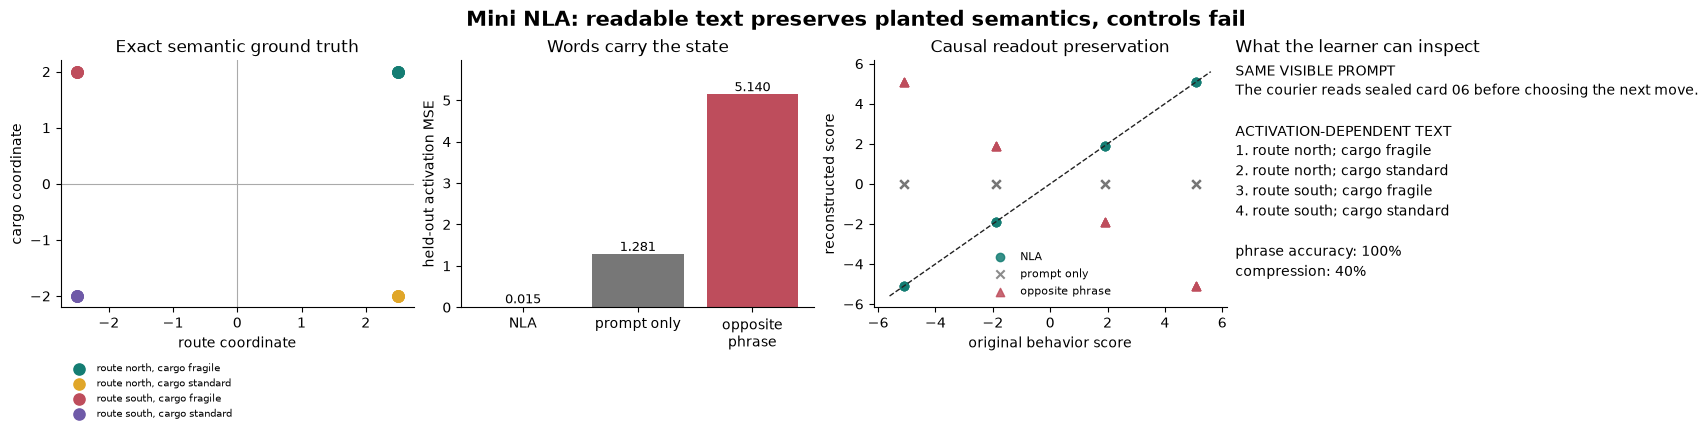

Saved arena_ext/assets/mini_nla_signature_result.png


In [11]:
dataset = signature["dataset"]
eval_mask = signature["eval_mask"]
eval_activations = dataset.activations[eval_mask]
semantic_xy = eval_activations @ dataset.semantic_directions.T
phrase_order = (
    "route north; cargo fragile",
    "route north; cargo standard",
    "route south; cargo fragile",
    "route south; cargo standard",
)
colors = {
    phrase_order[0]: "#147d73",
    phrase_order[1]: "#e0a629",
    phrase_order[2]: "#be4d5c",
    phrase_order[3]: "#6f5aa8",
}

fig, axes = plt.subplots(1, 4, figsize=(17, 4.2), constrained_layout=True)
for phrase in phrase_order:
    mask = t.tensor([value == phrase for value in signature["eval_phrases"]])
    axes[0].scatter(semantic_xy[mask, 0], semantic_xy[mask, 1], s=65, color=colors[phrase], label=phrase.replace(";", ","))
axes[0].axhline(0, color="#aaaaaa", linewidth=0.8)
axes[0].axvline(0, color="#aaaaaa", linewidth=0.8)
axes[0].set(xlabel="route coordinate", ylabel="cargo coordinate", title="Exact semantic ground truth")
axes[0].legend(fontsize=7, frameon=False, loc="center left", bbox_to_anchor=(0.0, -0.34))

mse_values = [reconstruction.nla_mse, reconstruction.prompt_only_mse, reconstruction.shuffled_phrase_mse]
bar_colors = ["#147d73", "#777777", "#be4d5c"]
axes[1].bar(["NLA", "prompt only", "opposite\nphrase"], mse_values, color=bar_colors)
axes[1].set(ylabel="held-out activation MSE", title="Words carry the state")
for i, value in enumerate(mse_values):
    axes[1].text(i, value + 0.08, f"{value:.3f}", ha="center", fontsize=9)
axes[1].set_ylim(0, max(mse_values) * 1.16)

original_behavior = eval_activations @ dataset.behavior_direction
for label, candidate, color, marker in [
    ("NLA", signature["nla_reconstruction"], "#147d73", "o"),
    ("prompt only", signature["prompt_only_reconstruction"], "#777777", "x"),
    ("opposite phrase", signature["shuffled_reconstruction"], "#be4d5c", "^"),
]:
    axes[2].scatter(original_behavior, candidate @ dataset.behavior_direction, label=label, color=color, marker=marker, alpha=0.85)
limit = float(original_behavior.abs().max()) + 0.5
axes[2].plot([-limit, limit], [-limit, limit], linestyle="--", color="#222222", linewidth=1)
axes[2].set(xlabel="original behavior score", ylabel="reconstructed score", title="Causal readout preservation")
axes[2].legend(frameon=False, fontsize=8)

axes[3].axis("off")
first_prompt = signature["eval_prompts"][0]
rows = [i for i, value in enumerate(signature["eval_prompts"]) if value == first_prompt]
text = "SAME VISIBLE PROMPT\n" + first_prompt + "\n\nACTIVATION-DEPENDENT TEXT\n"
text += "\n".join(f"{i + 1}. {signature['eval_phrases'][row]}" for i, row in enumerate(rows))
text += f"\n\nphrase accuracy: {signature['phrase_accuracy']:.0%}\ncompression: {signature['compression_ratio']:.0%}"
axes[3].text(0.0, 1.0, text, va="top", fontsize=10, linespacing=1.45)
axes[3].set_title("What the learner can inspect", loc="left")

fig.suptitle("Mini NLA: readable text preserves planted semantics, controls fail", fontsize=15, fontweight="bold")
asset_path = root_dir / "arena_ext" / "assets" / "mini_nla_signature_result.png"
asset_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(asset_path, dpi=220, bbox_inches="tight")
plt.show()
print(f"Saved {asset_path.relative_to(root_dir)}")

## Try It Yourself

Change `PLAY_NUISANCE_SCALE` and `PLAY_ROW`, then rerun the cell. Before running it, predict:

- whether the phrase encoder will still recover both bits;
- how much reconstruction MSE will rise as prompt nuisance grows;
- which phrase and behavior score will change after the route flip.

The default perturbation is causal: it edits only the planted route direction. Try increasing nuisance past the regime used in training to locate a genuine failure boundary.

In [12]:
PLAY_NUISANCE_SCALE = 0.60  # Change this; try 0.0, 0.35, 1.0, then larger values.
PLAY_ROW = 0  # Choose any held-out row from 0 to 15.
PLAY_FLIP_ROUTE = True

play = build_signature_payload(nuisance_scale=PLAY_NUISANCE_SCALE)
play_dataset = play["dataset"]
play_train = play_dataset.split_ids == 0
play_eval = play_dataset.split_ids == 1
play_weight, play_bias = fit_activation_encoder(
    play_dataset.activations[play_train], play_dataset.latent_bits[play_train]
)
original = play_dataset.activations[play_eval][PLAY_ROW : PLAY_ROW + 1]
perturbed = counterfactual_route_flip(original, play_dataset.semantic_directions[0]) if PLAY_FLIP_ROUTE else original
original_phrase, _ = encode_activations_to_phrases(original, play_weight, play_bias)
perturbed_phrase, _ = encode_activations_to_phrases(perturbed, play_weight, play_bias)
original_score = float((original @ play_dataset.behavior_direction).item())
perturbed_score = float((perturbed @ play_dataset.behavior_direction).item())
print("original phrase :", original_phrase[0])
print("perturbed phrase:", perturbed_phrase[0])
print(f"behavior score  : {original_score:+.3f} -> {perturbed_score:+.3f}")
print(f"held-out phrase accuracy at nuisance={PLAY_NUISANCE_SCALE:.2f}: {play['phrase_accuracy']:.1%}")
print(f"NLA reconstruction MSE: {play['reconstruction'].nla_mse:.4f}")

original phrase : route north; cargo fragile
perturbed phrase: route south; cargo fragile
behavior score  : +5.100 -> -1.900
held-out phrase accuracy at nuisance=0.60: 100.0%
NLA reconstruction MSE: 0.0450


## Bonus Anomaly Hunt

Find the smallest perturbation that breaks one claim while leaving the others intact. Good investigations include:

- rotate nuisance toward a semantic axis and measure when held-out phrase accuracy drops;
- remove one compositional phrase from training and test whether its two known words reconstruct it anyway;
- make the behavior direction depend on a discarded nuisance component and explain why low semantic error no longer guarantees behavioral faithfulness;
- replace the opposite-phrase control with random valid phrases over many seeds and plot the distribution, not just the mean.

A strong anomaly report names the hypothesis, perturbation, control, metric, and an example where the failure is visible.

## Real-Model Connection

Anthropic's Natural Language Autoencoder work studies learned activation-to-language and language-to-activation maps at a much larger scale. The exact organism here isolates the method's logic before the repository's pinned `gelu-1l` CUDA preflight: readable bottleneck, reconstruction, behavioral preservation, prompt-only control, wrong-text control, OOD prompts, and counterfactual activation change. The real-model verifier is supporting evidence and is not loaded into this lesson.

## Limitations

This notebook proves a narrow claim on an exact two-variable model organism. Its phrases come from a four-combination compositional vocabulary, the activation encoder is linear, and the phrase decoder is ridge regression. It does not demonstrate free-form explanation generation, arbitrary residual-stream reconstruction, discovery of unknown concepts, or Anthropic-scale NLA training. The pinned `gelu-1l` path must be rerun separately on CUDA before release, and its claims remain a small residual phrase-bottleneck preflight.

## Reading

- [Natural Language Autoencoders Produce Unsupervised Explanations of LLM Activations](https://transformer-circuits.pub/2026/nla/)
- [Anthropic: Natural Language Autoencoders](https://www.anthropic.com/research/natural-language-autoencoders)


## Verification Handoff

The visible signature result above is recomputed from the learner functions. The committed `verification_report.json` is supporting evidence for the separate pinned real-model preflight; loading it does not run CUDA. `run_gpu_test` and `run_full_experiment` run CUDA only when called explicitly.


In [13]:
def load_verification_evidence() -> dict:
    report = json.loads((section_dir / "verification_report.json").read_text())
    required = {"accepted", "metrics", "gt_tier", "notebook_id"}
    missing = sorted(required - report.keys())
    if missing:
        raise ValueError(f"verification report is missing required fields: {missing}")
    return report


def run_gpu_test(max_vram_gb: float = 24.0) -> dict:
    from importlib import import_module

    verification = import_module("chapter7_activation_to_language.exercises.part4_mini_natural_language_autoencoders.solutions")
    return verification.run_gpu_test(max_vram_gb=max_vram_gb)


def run_full_experiment(max_vram_gb: float = 24.0) -> dict:
    return run_gpu_test(max_vram_gb=max_vram_gb)


# Deliberately do not call the GPU entry points during CPU notebook execution.
